# 02 — Descriptive Analysis

**Input**: `data/processed/anonymized.csv` (and auxiliary long-form files)

**Outputs**: PDF figures in `figures/` + tables in `data/processed/tables/`

**Goals**:
- Consolidated demographic Table 2 (replaces 3 figures)
- Diverging stacked bar for skills (Q8), importance (Q11), priority (Q13)
- Discussion and support frequency (Q19, Q22)
- Bar chart of Q9 words (raw frequency — lemmatization goes to notebook 04)
- Table with Wilson 95% CI for all main proportions
- Replace the 11 `example-image-duck` placeholders

In [28]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
words = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)}, importance={len(imp_long)}, priority={len(pri_long)}")

N=51, importance=663, priority=663


## Demographic characterization

In [29]:
def freq_table(series: pd.Series, label: str, order=None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(1)
    out = pd.DataFrame({"Category": counts.index, "n": counts.values, "%": pct.values})
    out.insert(0, "Variable", "")
    out.iloc[0, 0] = label
    return out

blocks = [
    freq_table(df["gender_norm"], "Gender"),
    freq_table(df["age_band"], "Age band",
               order=["18-24 years", "25-34 years", "35-44 years", "45-54 years", "55-64 years"]),
    freq_table(df["norm_country"], "Country"),
    freq_table(df["education_norm"], "Education"),
    freq_table(df["role_group"], "Role"),
    freq_table(df["seniority_norm"], "Seniority"),
]
demo_table = pd.concat(blocks, ignore_index=True)
demo_table = demo_table[demo_table["n"] > 0].reset_index(drop=True)
demo_table

,Variable,Category,n,%
0,Gender,male,41,80.4
1,,female,10,19.6
2,Country,Brazil,38,74.5
3,,United States,5,9.8
4,,Germany,4,7.8
5,,France,2,3.9
6,,Colombia,1,2.0
7,,China,1,2.0
8,Education,Doctoral student,17,33.3
9,,Doctorate,9,17.6


In [69]:
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── Palettes (extended so they never run short as N grows) ────────────────────
_TEAL   = ["#0F6E56", "#1D9E75", "#5DCAA5", "#9FE1CB", "#C5F0E3", "#E0F8F2"]
_BLUE   = ["#01579B", "#0277BD", "#00ACC1", "#80DEEA", "#B2EBF2", "#E0F7FA"]
_PURPLE = ["#231A6B", "#3C3489", "#524DB5", "#6B66D0", "#7F77DD", "#9590E6", "#ADAAF0", "#C5C3F7"]
_CORAL  = ["#993C1D", "#D85A30", "#F0997B", "#F5C4B3", "#FAE0D6", "#FDF0EC"]
_BG = "#FAFAF8"

# ── Data ─────────────────────────────────────────────────────────────────────
# 1. Age Band — oldest→youngest (top→bottom in funnel)
_age = (df["age_band"].value_counts()
        .reindex(["45-54", "35-44", "25-34", "18-24"])
        .dropna().astype(int))

# 2. Seniority — short labels; Intern at bottom, Senior at top
_SEN_SHORT = {
    "Intern":                   "Intern",
    "Junior (up to 5 years)":   "Junior",
    "Mid-level (6 to 9 years)": "Mid-level",
    "Senior (10+ years)":       "Senior",
}
_sen = (df["seniority_norm"].map(_SEN_SHORT).value_counts()
        .reindex(list(_SEN_SHORT.values())).dropna().astype(int))

# 3. Country — largest bubble centred, rest in tight ring
_cvc = df["norm_country"].value_counts()
_cdf = pd.DataFrame({"country": _cvc.index, "n": _cvc.values}).sort_values("n", ascending=False).reset_index(drop=True)
_nc  = len(_cdf)
_ang = [2 * np.pi * i / max(_nc - 1, 1) + np.pi / 5 for i in range(_nc - 1)]
_bx  = [0.0] + [0.65 * np.cos(a) for a in _ang]  
_by  = [0.0] + [0.4 * np.sin(a) for a in _ang] 

idx_germany = _cdf.index[_cdf["country"] == "Germany"][0]
_bx[idx_germany] -= 0.15  

idx_colombia = _cdf.index[_cdf["country"] == "Colombia"][0]
_bx[idx_colombia] -= 0.10  

_bsz = (np.sqrt(_cdf["n"]) / np.sqrt(_cdf["n"].max()) * 115 + 54).tolist()

# 4. N Projects — binned
_np_raw = df["n_projects"].dropna().astype(int)
_np_ser = pd.cut(_np_raw, bins=[-1, 3, 7, 15, int(_np_raw.max()) + 1],
                 labels=["0–3", "4–7", "8–15", "16+"]).value_counts().sort_index()

# ── Figure (2×2) ─────────────────────────────────────────────────────────────
fig_demo = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "funnel"}, {"type": "xy"}],
           [{"type": "xy"},     {"type": "xy"}]],
    subplot_titles=["Age Band", "Seniority", "Country", "Number of ML Projects"],
    horizontal_spacing=0.04,  # reduzido
    vertical_spacing=0.08,    # reduzido
)

# 1 — Funnel (row 1, col 1)
fig_demo.add_trace(go.Funnel(
    y=_age.index.tolist(), x=_age.values.tolist(),
    textinfo="value",
    textfont=dict(color="white", size=15, family="sans-serif"),
    marker=dict(color=_TEAL[:len(_age)], line=dict(color="white", width=1.2)),
    connector=dict(line=dict(color="rgba(0,0,0,0)", width=0)),
), row=1, col=1)

# 2 — Horizontal bar (Seniority) — leading spaces create gap between label and bar
fig_demo.add_trace(go.Bar(
    y=["  " + lbl for lbl in _sen.index.tolist()], x=_sen.values.tolist(),
    orientation="h",
    marker=dict(color=_BLUE[:len(_sen)], line=dict(color="white", width=0.8)),
    text=_sen.values.tolist(), textposition="inside",
    insidetextanchor="middle",
    textfont=dict(color="white", size=15),
    width=0.58,
), row=1, col=2)

# 3 — Bubble (Country) (row 2, col 1)
fig_demo.add_trace(go.Scatter(
    x=_bx, y=_by,
    mode="markers+text",
    marker=dict(size=_bsz, color=_PURPLE[:_nc], opacity=0.88,
                line=dict(color="white", width=2.0), sizemode="diameter"),
    text=[f"<b>{c}</b><br>{n}" for c, n in zip(_cdf["country"], _cdf["n"])],
    textposition="middle center",
    textfont=dict(color="white", size=13, family="sans-serif"),
    hovertemplate="%{text}<extra></extra>", cliponaxis=False
), row=2, col=1)

# 4 — Vertical bar (N Projects) (row 2, col 2)
fig_demo.add_trace(go.Bar(
    x=_np_ser.index.tolist(), y=_np_ser.values.tolist(),
    marker=dict(color=_CORAL[:len(_np_ser)], line=dict(color="white", width=0.8)),
    text=_np_ser.values.tolist(), textposition="outside",
    textfont=dict(size=15), width=0.55, cliponaxis=False
), row=2, col=2)

# ── Styling ───────────────────────────────────────────────────────────────────
fig_demo.update_layout(
    title=dict(text="Demographic characterization",
               font=dict(size=19, color="#2C2C2A", family="sans-serif"),
               x=0.5, xanchor="center"),
    paper_bgcolor=_BG, plot_bgcolor=_BG,
    showlegend=False, height=580,
    margin=dict(t=65, b=30, l=10, r=10),
    font=dict(family="sans-serif", size=10, color="#2C2C2A"),
)
# Seniority (row 1, col 2)
fig_demo.update_xaxes(showgrid=False, zeroline=False, showticklabels=False,
                      range=[-1.5, int(_sen.max()) + 1], row=1, col=2)
fig_demo.update_yaxes(showgrid=False, zeroline=False, row=1, col=2)
# Country (row 2, col 1)
fig_demo.update_xaxes(showgrid=False, zeroline=False, showticklabels=False,
                      range=[-0.82, 0.82], row=2, col=1)
fig_demo.update_yaxes(showgrid=False, zeroline=False, showticklabels=False,
                      range=[-0.56, 0.56], row=2, col=1)
# Projects (row 2, col 2)
fig_demo.update_xaxes(showgrid=False, zeroline=False, row=2, col=2)
fig_demo.update_yaxes(showgrid=False, zeroline=False, showticklabels=False, row=2, col=2)

fig_demo.show()

In [31]:
edu_order = [
    "phd_student", 
    "doctorate", 
    "undergraduate", 
    "ms_student", 
    "master", 
    "specialization"
]
edu_ser = df["education_norm"].value_counts().reindex(edu_order)
edu_ser

education_norm
phd_student      NaN
doctorate        NaN
undergraduate    NaN
ms_student       NaN
master           NaN
specialization   NaN
Name: count, dtype: float64

In [32]:
# # projects: descriptive stats
proj = df["n_projects"]
proj_stats = pd.Series({
    "min": int(proj.min()),
    "Q1": float(proj.quantile(0.25)),
    "median": float(proj.median()),
    "Q3": float(proj.quantile(0.75)),
    "max": int(proj.max()),
    "mean": float(proj.mean()),
})
print("ML projects already participated in:")
print(proj_stats.round(1).to_string())

ML projects already participated in:
min        0.0
Q1         2.0
median     4.0
Q3         6.5
max       40.0
mean       6.1


In [33]:
# Saves LaTeX table that will go in as Table 2 in the paper
def df_to_latex_demo(df: pd.DataFrame) -> str:
    lines = [
        "\\begin{table}[t]",
        "\\caption{Respondent characterization ($n=32$).}",
        "\\label{tab:demographics}",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lp{4.5cm}rr}",
        "\\toprule",
        "\\textbf{Variable} & \\textbf{Category} & \\textbf{n} & \\textbf{\\%} \\\\",
        "\\midrule",
    ]
    for _, row in df.iterrows():
        var = row["Variable"] if row["Variable"] else ""
        cat = str(row["Category"]).replace("_", "\\_")
        lines.append(f"{var} & {cat} & {row['n']} & {row['%']:.1f} \\\\")
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
    return "\n".join(lines)

(TABLES / "demographics.tex").write_text(df_to_latex_demo(demo_table))
print("[saved] tables/demographics.tex")

[saved] tables/demographics.tex


## 2. Diverging stacked bar — generic function

Centers Likerts at Neutral=0. Negatives go to the left, positives to the right.

In [34]:
def diverging_stacked(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    item_labels: dict[str, str],
    level_labels: list[str],
    title: str,
    figsize: tuple[float, float] = (7.0, 4.5),
    palette: list[str] | None = None,
    sort_by_positive: bool = True,
    ci_df: pd.DataFrame | None = None,
) -> plt.Figure:
    """Diverging stacked bar for Likerts with optional Wilson 95% CI error bars.

    Parameters
    ----------
    long_df : long format with columns [item_col, value_col]; value_col is int 1..N
    item_labels : dict of key (in item_col) -> nice label for the y-axis
    level_labels : list of N labels (1st = most negative). If 5 levels, 3rd is neutral.
    ci_df : optional DataFrame indexed by item keys with columns
            'pct_top2', 'ci_lo', 'ci_hi' (all in percent, 0-100).
            When provided, draws a horizontal error bar on the positive side of each bar.
    """
    n_levels = len(level_labels)
    if palette is None:
        palette = U.PALETTE_LIKERT_5 if n_levels == 5 else None
    items = list(item_labels.keys())
    counts = (long_df.groupby(item_col)[value_col]
              .value_counts().unstack(fill_value=0)
              .reindex(index=items, columns=range(1, n_levels + 1), fill_value=0))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    if sort_by_positive:
        positive = pct[[n_levels - 1, n_levels]] if n_levels >= 4 else pct[[n_levels]]
        order = positive.sum(axis=1).sort_values().index
        pct = pct.loc[order]
        items = list(order)
    # Center: for 5 levels, neutral is 3 (central index). Negatives {1,2}, Positives {4,5}.
    if n_levels == 5:
        neg_levels, neutral, pos_levels = [1, 2], 3, [4, 5]
    elif n_levels == 4:
        neg_levels, neutral, pos_levels = [1, 2], None, [3, 4]
    else:
        raise ValueError("diverging_stacked expects 4 or 5 levels")

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(items))
    # Negatives: stack with sign flipped, from outermost (1) to most central (2)
    left_offset = -pct[neg_levels[1]].values - pct[neg_levels[0]].values
    cur = left_offset.copy()
    for lvl, color in zip(neg_levels, palette[:len(neg_levels)]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, color=color,
                edgecolor="white", linewidth=0.5, label=level_labels[lvl - 1])
        cur += widths
    if neutral is not None:
        widths = pct[neutral].values
        # Center neutral around 0
        ax.barh(y, widths, left=-widths / 2, color=palette[neutral - 1],
                edgecolor="white", linewidth=0.5, label=level_labels[neutral - 1])
    cur = (pct[neutral].values / 2) if neutral is not None else np.zeros(len(items))
    for lvl, color in zip(pos_levels, palette[-len(pos_levels):]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, color=color,
                edgecolor="white", linewidth=0.5, label=level_labels[lvl - 1])
        cur += widths

    # ── Wilson 95% CI error bars ──────────────────────────────────────────
    if ci_df is not None:
        ci_aligned = ci_df.reindex(items)

        # Offset do lado positivo: metade do neutro (igual ao `cur` antes do loop positivo)
        neutral_offset = (pct[neutral].values / 2) if neutral is not None else np.zeros(len(items))

        # Centro da barra de erro = onde pct_top2 cai no eixo divergente
        x_center = neutral_offset + ci_aligned["pct_top2"].values
        x_lo_err = np.clip(x_center - (neutral_offset + ci_aligned["ci_lo"].values), 0, None)
        x_hi_err = np.clip((neutral_offset + ci_aligned["ci_hi"].values) - x_center, 0, None)

        ax.errorbar(
            x_center, y,
            xerr=[x_lo_err, x_hi_err],
            fmt="none",
            ecolor="black",
            elinewidth=1.0,
            capsize=3,
            capthick=1.0,
            zorder=5,
            label="95% CI (Wilson)",
        )

    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels([item_labels[i] for i in items])
    ax.set_xlabel("% of responses")
    ax.set_xlim(-100, 100)
    ax.set_xticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(["100%", "75%", "50%", "25%", "0", "25%", "50%", "75%", "100%"])
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
              ncol=n_levels + (1 if ci_df is not None else 0), frameon=False)
    return fig

In [35]:
def _bootstrap_ci(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    items: list,
    top_levels: list[int],
    n_bootstrap: int = 2000,
    ci_level: float = 0.95,
    random_state: int | None = 42,
) -> pd.DataFrame:
    """Compute % top-2 and Bootstrap CI for each item in *items*.

    Parameters
    ----------
    long_df    : long-format DataFrame with columns [item_col, value_col]
    items      : list of keys (values in item_col)
    top_levels : iterable of Likert values that count as "positive" (e.g. [4, 5])
    n_bootstrap: number of bootstrap resamples (default 2000)
    ci_level   : confidence level, e.g. 0.95 for 95% CI (default 0.95)
    random_state: seed for reproducibility (default 42)

    Returns
    -------
    DataFrame indexed by item key with columns pct_top2, ci_lo, ci_hi (all in %).
    """
    rng = np.random.default_rng(random_state)
    alpha = 1 - ci_level
    rows = {}

    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)
        if n == 0:
            rows[key] = {"pct_top2": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan")}
            continue

        vals = s.values
        pct_top2 = s.isin(top_levels).mean() * 100

        boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
        boot_props = np.isin(vals[boot_indices], top_levels).mean(axis=1) * 100

        lo = np.percentile(boot_props, 100 * alpha / 2)
        hi = np.percentile(boot_props, 100 * (1 - alpha / 2))
        rows[key] = {"pct_top2": pct_top2, "ci_lo": lo, "ci_hi": hi}

    return pd.DataFrame(rows).T

## 3. Skills (Q8) — replaces 5 figures with 1

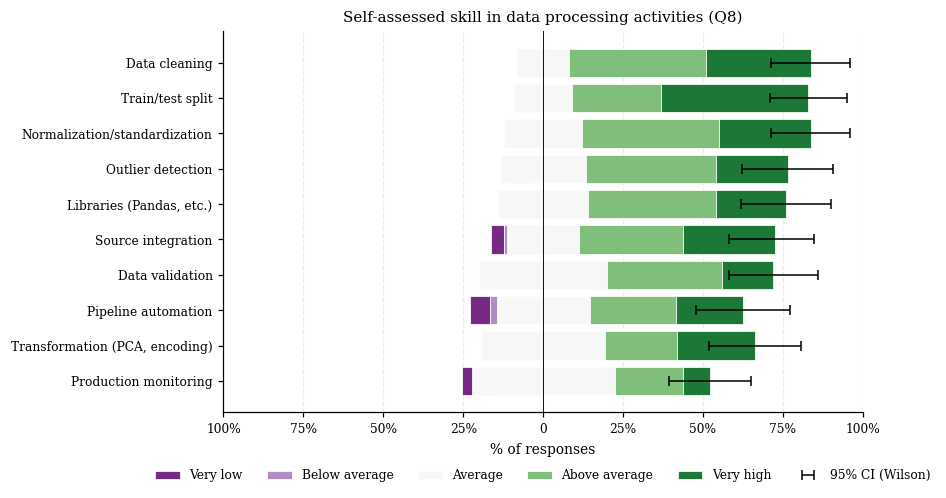

In [36]:
skills_renamed = skills_long.copy()
_skill_items = list(U.SKILL_LABELS_PT.keys())
_skill_ci = _bootstrap_ci(
    skills_renamed.dropna(), "activity", "skill", _skill_items, top_levels=[4, 5]
)
fig = diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_PT,
    level_labels=["Very low", "Below average", "Average", "Above average", "Very high"],
    title="Self-assessed skill in data processing activities (Q8)",
    figsize=(7.5, 4.5),
    ci_df=_skill_ci,
)
U.save_fig(fig, "skills_diverging")
plt.show()

## 9. Table with Wilson 95% CI for main proportions

In [37]:
rng = np.random.default_rng(42)

def _boot_ci(values: np.ndarray, n_bootstrap: int = 2000) -> tuple[float, float]:
    """Percentile bootstrap CI for the proportion of values >= 4."""
    n = len(values)
    boot_props = np.mean(values[rng.integers(0, n, size=(n_bootstrap, n))] >= 4, axis=1)
    return np.percentile(boot_props, 2.5), np.percentile(boot_props, 97.5)

rows = []
for char_key, char_label in U.CHARACTERISTICS_PT.items():
    imp_col = f"imp_{char_key}"
    pri_col = f"pri_{char_key}"
    vals_imp = df[imp_col].dropna().values
    vals_pri = df[pri_col].dropna().values
    suc_imp = (vals_imp >= 4).sum()
    suc_pri = (vals_pri >= 4).sum()
    lo_i, hi_i = _boot_ci(vals_imp)
    lo_p, hi_p = _boot_ci(vals_pri)
    rows.append({
        "Characteristic": char_label,
        "% Important/Very": f"{suc_imp/len(vals_imp)*100:.0f}%",
        "CI95 (imp.)": f"[{lo_i*100:.0f}–{hi_i*100:.0f}]",
        "% High/Essential": f"{suc_pri/len(vals_pri)*100:.0f}%",
        "CI95 (pri.)": f"[{lo_p*100:.0f}–{hi_p*100:.0f}]",
        "n": len(vals_imp),
    })

ci_table = pd.DataFrame(rows)
ci_table["_sort"] = ci_table["% Important/Very"].str.rstrip("%").astype(float)
ci_table = ci_table.sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)
ci_table

,Characteristic,% Important/Very,CI95 (imp.),% High/Essential,CI95 (pri.),n
0,Completeness,96%,[90–100],84%,[75–94],51
1,Precision,94%,[88–100],92%,[84–98],51
2,Reliability,94%,[86–100],84%,[75–94],51
3,Credibility,92%,[84–98],84%,[73–94],51
4,Consistency,92%,[84–98],86%,[76–94],51
5,Availability,84%,[75–94],73%,[61–84],51
6,Efficiency,76%,[65–88],63%,[49–76],51
7,Traceability,75%,[63–86],57%,[43–71],51
8,Currentness,69%,[55–80],47%,[33–61],51
9,Understandability,69%,[55–80],59%,[45–71],51


## 11. Aggregated skills — % "Above average/Very high"

In [38]:
# LaTeX table with proportions + CI
def df_to_latex_ci(df: pd.DataFrame) -> str:
    lines = [
        "\\begin{table}[t]",
        "\\caption{Proportions of \\textit{Important/Very important} (Q11) and \\textit{High priority/Essential} (Q13) responses with Bootstrap 95\\% CI ($n=32$).}",
        "\\label{tab:characteristics-ci}",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lcccc}",
        "\\toprule",
        "\\textbf{Characteristic} & \\textbf{\\% Imp.} & \\textbf{95\\% CI} & \\textbf{\\% Pri.} & \\textbf{95\\% CI} \\\\",
        "\\midrule",
    ]
    for _, r in df.iterrows():
        lines.append(f"{r['Characteristic']} & {r['% Important/Very']} & {r['CI95 (imp.)']} & {r['% High/Essential']} & {r['CI95 (pri.)']} \\\\")
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
    return "\n".join(lines)

(TABLES / "characteristics_ci.tex").write_text(df_to_latex_ci(ci_table))
print("[saved] tables/characteristics_ci.tex")

skill_pct = []
for col in U.SKILL_COLS:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    lo, hi = _boot_ci(s.values)
    skill_pct.append({
        "Activity": U.SKILL_LABELS_PT[col],
        "% High": (s >= 4).mean() * 100,
        "CI95": f"[{lo*100:.0f}–{hi*100:.0f}]",
        "n": int(len(s)),
    })
skill_pct_df = pd.DataFrame(skill_pct).sort_values("% High", ascending=False).reset_index(drop=True)
skill_pct_df.round(1)

[saved] tables/characteristics_ci.tex


,Activity,% High,CI95,n
0,Data cleaning,75.5,[63–88],49
1,Train/test split,74.0,[62–86],50
2,Normalization/standardization,71.4,[59–84],49
3,Outlier detection,63.3,[49–76],49
4,"Libraries (Pandas, etc.)",62.0,[48–74],50
5,Source integration,61.2,[47–73],49
6,Data validation,52.0,[38–66],50
7,Pipeline automation,47.9,[35–62],48
8,"Transformation (PCA, encoding)",46.9,[33–61],49
9,Production monitoring,29.8,[17–43],47


## 4. Importance (Q11) — 13 characteristics

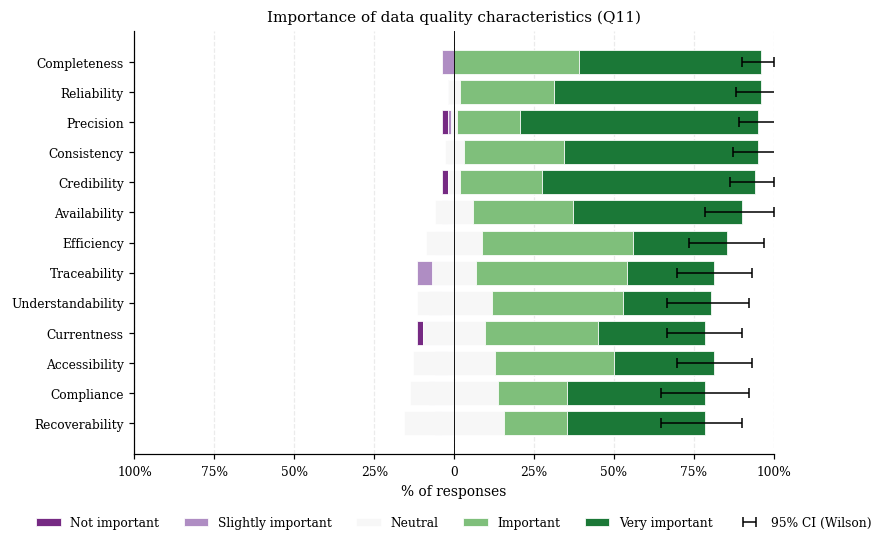

In [39]:
imp_renamed = imp_long.copy()
_imp_items = list(U.CHARACTERISTICS_PT.keys())
_imp_ci = _bootstrap_ci(
    imp_renamed, "characteristic", "importance", _imp_items, top_levels=[4, 5]
)
fig = diverging_stacked(
    imp_renamed,
    item_col="characteristic",
    value_col="importance",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not important", "Slightly important", "Neutral", "Important", "Very important"],
    title="Importance of data quality characteristics (Q11)",
    figsize=(7.5, 5.0),
    ci_df=_imp_ci,
)
U.save_fig(fig, "importance_diverging")
plt.show()

## 5. Priority (Q13) — 13 characteristics

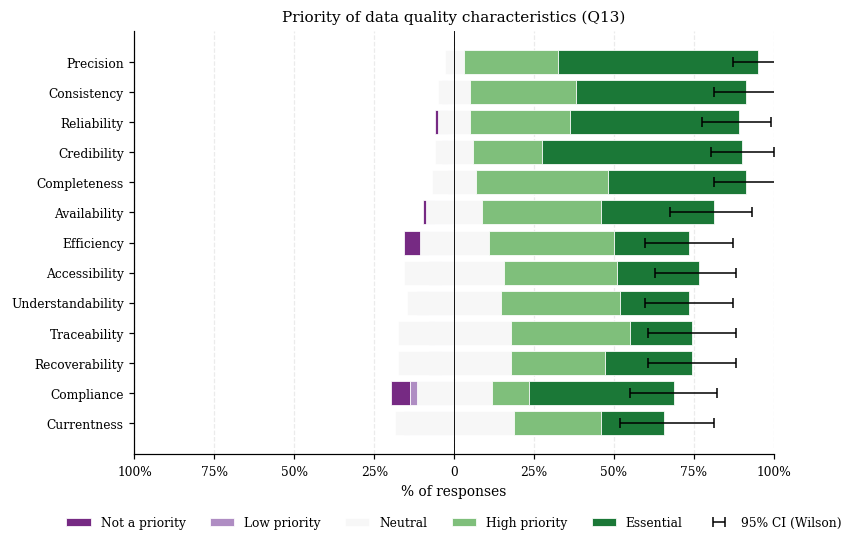

In [40]:
_pri_items = list(U.CHARACTERISTICS_PT.keys())
_pri_ci = _bootstrap_ci(
    pri_long, "characteristic", "priority", _pri_items, top_levels=[4, 5]
)
fig = diverging_stacked(
    pri_long,
    item_col="characteristic",
    value_col="priority",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not a priority", "Low priority", "Neutral", "High priority", "Essential"],
    title="Priority of data quality characteristics (Q13)",
    figsize=(7.5, 5.0),
    ci_df=_pri_ci,
)
U.save_fig(fig, "priority_diverging")
plt.show()

## 7. Frequencies (Q19 discussion + Q22 support)

Two distributions in 1 figure sharing aesthetics.

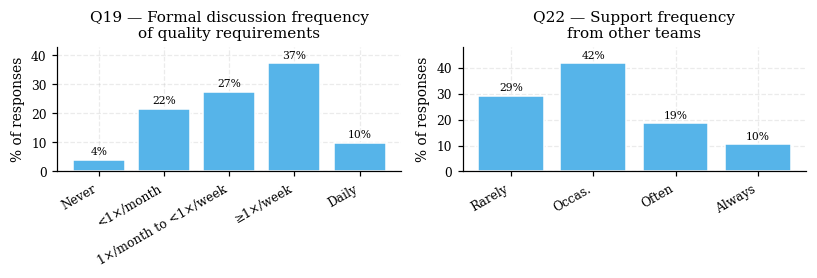

In [41]:
disc_labels = ["Never", "<1×/month", "1×/month to <1×/week", "≥1×/week", "Daily"]
supp_labels = ["Rarely", "Occas.", "Often", "Always"]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.6))

for ax, col, labels, title in [
    (axes[0], "discussion_freq", disc_labels,
     "Q19 — Formal discussion frequency\nof quality requirements"),
    (axes[1], "support_freq", supp_labels,
     "Q22 — Support frequency\nfrom other teams"),
]:
    counts = df[col].value_counts(dropna=False).reindex(range(1, len(labels) + 1), fill_value=0)
    pct = counts / counts.sum() * 100
    ax.bar(range(len(labels)), pct.values, color=U.PALETTE_WONG[2], edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("% of responses")
    ax.set_title(title)
    ax.set_ylim(0, max(pct.values) * 1.15)
    for i, v in enumerate(pct.values):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=7)

fig.tight_layout()
U.save_fig(fig, "frequencies")
plt.show()

## 10. Heatmap subgroups × characteristics (% top-2)

Rows = subgroup, columns = characteristic, value = % "Important/Very important". Quickly highlights visual differences (Diversity Matters style).

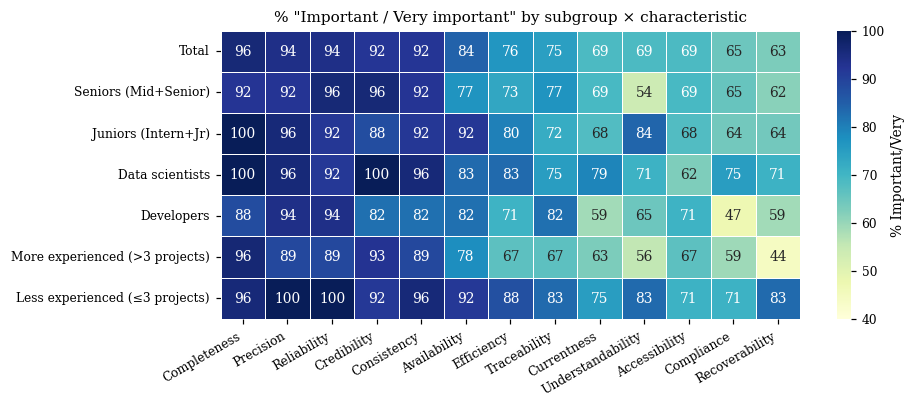

In [42]:
def pct_top2(df_sub: pd.DataFrame, col: str) -> float:
    s = df_sub[col].dropna()
    if len(s) == 0:
        return float("nan")
    return (s >= 4).sum() / len(s) * 100

groups = {
    "Total": df,
    "Seniors (Mid+Senior)": df[df["seniority_group"] == "senior"],
    "Juniors (Intern+Jr)": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More experienced (>3 projects)": df[df["n_projects"] > 3],
    "Less experienced (≤3 projects)": df[df["n_projects"] <= 3],
}

heat = pd.DataFrame(
    {label: [pct_top2(g, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()] for label, g in groups.items()},
    index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()],
).T
# Sort columns by total %
heat = heat[heat.loc["Total"].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "% Important/Very"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=40, vmax=100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("% \"Important / Very important\" by subgroup × characteristic")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_importance_subgroups")
plt.show()

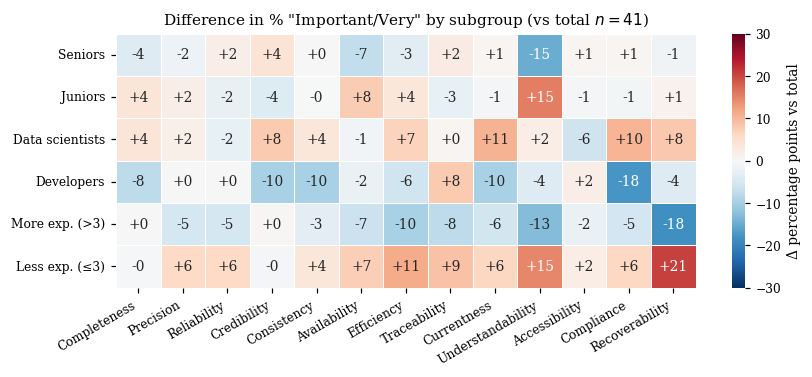

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
U.setup_matplotlib()

def pct_top2(g, col):
    s = g[col].dropna()
    return (s >= 4).sum() / len(s) * 100 if len(s) else np.nan

groups_def = {
    "Seniors": df[df["seniority_group"] == "senior"],
    "Juniors": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More exp. (>3)": df[df["n_projects"] > 3],
    "Less exp. (≤3)": df[df["n_projects"] <= 3],
}
total_imp = pd.Series({c: pct_top2(df, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()})
diffs = pd.DataFrame({
    label: [pct_top2(g, f"imp_{c}") - total_imp[c] for c in U.CHARACTERISTICS_PT.keys()]
    for label, g in groups_def.items()
}, index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()]).T
diffs = diffs[total_imp.sort_values(ascending=False).rename(lambda c: U.CHARACTERISTICS_PT[c]).index]

fig, ax = plt.subplots(figsize=(8.5, 3.0))
sns.heatmap(diffs, annot=True, fmt="+.0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Δ percentage points vs total"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=-30, vmax=30)
ax.set_title("Difference in % \"Important/Very\" by subgroup (vs total $n=41$)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_subgroup_diff")
plt.show()

## 12. Final descriptive summary

In [44]:
# Key findings the paper needs to cite
summary = {
    "n": len(df),
    "n_pt": int((df["language"] == "pt").sum()),
    "n_en": int((df["language"] == "en").sum()),
    "%_men": (df["gender_norm"] == "male").mean() * 100,
    "%_NE": (df["region"] == "Northeast").mean() * 100,
    "%_international": (df["region"] == "International").mean() * 100,
    "%_DS": (df["role_group"] == "data_scientist").mean() * 100,
    "%_seniors": (df["seniority_group"] == "senior").mean() * 100,
    "projects_median": int(df["n_projects"].median()),
    "%_disc_<1month": ((df["discussion_freq"] <= 2).sum() / df["discussion_freq"].notna().sum() * 100),
    "%_supp_<=occasional": ((df["support_freq"] <= 2).sum() / df["support_freq"].notna().sum() * 100),
    "most_imp_charac": ci_table.iloc[0]["Characteristic"],
    "least_imp_charac": ci_table.iloc[-1]["Characteristic"],
}
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.1f}")
    else:
        print(f"{k}: {v}")

import json
(TABLES / "descriptive_summary.json").write_text(json.dumps({k: (float(v) if isinstance(v, (int, float)) else v) for k, v in summary.items()}, ensure_ascii=False, indent=2))
print("\n[saved] tables/descriptive_summary.json")

n: 51
n_pt: 32
n_en: 19
%_men: 80.4
%_NE: 45.1
%_international: 25.5
%_DS: 47.1
%_seniors: 51.0
projects_median: 4
%_disc_<1month: 25.5
%_supp_<=occasional: 72.0
most_imp_charac: Completeness
least_imp_charac: Recoverability

[saved] tables/descriptive_summary.json


## 13. Internal reliability — Cronbach α and McDonald ω

Before treating Q11/Q13 as aggregated "constructs" (e.g., "% High Importance"),
we measure internal consistency of the blocks as Likert scales.

- **Cronbach α**: assumes tau-equivalence; pingouin returns a bootstrap 95% CI.
- **McDonald ω total**: 1-factor analysis on standardized items (`U.mcdonald_omega`); less sensitive to tau-equivalence violations.

Convention: α ≥ 0.7 acceptable, ≥ 0.8 good, ≥ 0.9 excellent (Nunnally 1978).


In [45]:
import pingouin as pg

def reliability_block(name: str, items: pd.DataFrame) -> dict:
    items = items.dropna()
    alpha, ci = pg.cronbach_alpha(data=items)
    omega = U.mcdonald_omega(items)
    return {"block": name, "n_subj": len(items), "k_items": items.shape[1],
            "cronbach_alpha": float(alpha),
            "alpha_ci_lo": float(ci[0]), "alpha_ci_hi": float(ci[1]),
            "mcdonald_omega": omega}

reli_imp = reliability_block("Q11 importance", df[U.IMP_COLS])
reli_pri = reliability_block("Q13 priority", df[U.PRI_COLS])
reli_skill = reliability_block("Q8 skills", df[U.SKILL_COLS])

reliability = pd.DataFrame([reli_imp, reli_pri, reli_skill])
print(reliability.to_string(index=False))
print()
for r in [reli_imp, reli_pri, reli_skill]:
    interp = (
        "excellent" if r["cronbach_alpha"] >= 0.9 else
        "good" if r["cronbach_alpha"] >= 0.8 else
        "acceptable" if r["cronbach_alpha"] >= 0.7 else
        "questionable" if r["cronbach_alpha"] >= 0.6 else
        "inadequate"
    )
    print(f"{r['block']}: α={r['cronbach_alpha']:.3f} "
          f"[{r['alpha_ci_lo']:.3f}, {r['alpha_ci_hi']:.3f}], "
          f"ω={r['mcdonald_omega']:.3f} — {interp} reliability.")


         block  n_subj  k_items  cronbach_alpha  alpha_ci_lo  alpha_ci_hi  mcdonald_omega
Q11 importance      51       13        0.911378        0.871        0.943        0.914296
  Q13 priority      51       13        0.898615        0.852        0.935        0.901858
     Q8 skills      45       10        0.921159        0.882        0.951        0.923650

Q11 importance: α=0.911 [0.871, 0.943], ω=0.914 — excellent reliability.
Q13 priority: α=0.899 [0.852, 0.935], ω=0.902 — good reliability.
Q8 skills: α=0.921 [0.882, 0.951], ω=0.924 — excellent reliability.


In [46]:
reliability.to_csv(TABLES / "reliability.csv", index=False)
print(f"-> tables/reliability.csv")


-> tables/reliability.csv


In [47]:
pd.set_option('display.max_columns', None)
df.head()

,language,timestamp,age,state,gender,education,role,seniority,n_projects,skill_cleaning,skill_normalization,skill_outliers,skill_integration,skill_transformation,skill_validation,skill_pipelines,skill_monitoring,skill_libs,skill_split,word_1,word_2,word_3,word_4,word_5,re_experience,imp_precision,imp_completeness,imp_consistency,imp_credibility,imp_currentness,imp_accessibility,imp_compliance,imp_reliability,imp_efficiency,imp_traceability,imp_understandability,imp_availability,imp_recoverability,imp_justification,pri_precision,pri_completeness,pri_consistency,pri_credibility,pri_currentness,pri_accessibility,pri_compliance,pri_reliability,pri_efficiency,pri_traceability,pri_understandability,pri_availability,pri_recoverability,pri_justification,balance_open,versioning_open,incorporation_open,measurement_open,discussion_freq,documentation_open,challenges_open,support_freq,state_raw,country,region,norm_country,n_projects_raw,skill_cleaning_raw,skill_normalization_raw,skill_outliers_raw,skill_integration_raw,skill_transformation_raw,skill_validation_raw,skill_pipelines_raw,skill_monitoring_raw,skill_libs_raw,skill_split_raw,imp_precision_raw,imp_completeness_raw,imp_consistency_raw,imp_credibility_raw,imp_currentness_raw,imp_accessibility_raw,imp_compliance_raw,imp_reliability_raw,imp_efficiency_raw,imp_traceability_raw,imp_understandability_raw,imp_availability_raw,imp_recoverability_raw,pri_precision_raw,pri_completeness_raw,pri_consistency_raw,pri_credibility_raw,pri_currentness_raw,pri_accessibility_raw,pri_compliance_raw,pri_reliability_raw,pri_efficiency_raw,pri_traceability_raw,pri_understandability_raw,pri_availability_raw,pri_recoverability_raw,discussion_freq_raw,support_freq_raw,seniority_ordinal,seniority_norm,seniority_group,role_group,gender_norm,age_band,education_norm,word_1_raw,word_2_raw,word_3_raw,word_4_raw,word_5_raw
0,pt,2025-02-14 15:15:25,18-24 anos,CE,Homem,Ensino superior,Cientista de dados,Júnior (até 5 anos),2,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,precisão,consistência,completude,relevância,viés,"Sim, foi uma ótima experiência, embora complic...",4,4,4,4,4,4,4,4,4,4,4,4,4,NaN,4,4,4,4,4,4,4,4,4,4,4,4,4,NaN,"Equilibrar precisão, compreensibilidade e efic...",Garante a consistência e rastreabilidade dos d...,Avaliação inicial durante a coleta e preparaçã...,Análise de métricas de performance (ex.: preci...,3,"Linguagem estruturada (texto), Ferramentas de ...",Inconsistência entre diferentes fontes de dado...,2.0,Ceará,Brazil,Northeast,Brazil,2,Média,Média,Média,Média,Média,Média,Média,Média,Média,Média,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Importante,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,Alta prioridade,"Menos de uma vez por semana, mas pelo menos um...",Ocasionalmente,2,Junior (up to 5 years),junior,data_scientist,male,18-24,Undergraduate,Precisão,Consistência,Completude,Relevância,Viés
1,pt,2025-02-14 15:46:32,25-34 anos,PE,Mulher,Estudante de Doutorado,Cientista de dados,Júnior (até 5 anos),2,5.0,5.0,5.0,3.0,4.0,4.0,3.0,3.0,4.0,5.0,fonte,estabilidade,necessário,essencial,determinante,Não,5,4,5,5,5,5,5,5,5,4,5,5,5,NaN,5,4,5,5,5,5,5,5,5,4,5,5,4,NaN,"A prioridade é na precisão dos dados, seguido ...",Garante a consistência e rastreabilidade dos d...,Avaliação inicial durante a coleta e preparaçã...,Análise de métricas de performance (ex.: preci...,4,"Linguagem estruturada (texto), Reuniões de Ali...","Dados incompletos ou ausentes, Dados desatuali...",2.0,PE,Brazil,Northeast,Brazil,2,Muito alto,Muito alto,Muito alto,Média,Acima da média,Acima da média,Média,Média,Acima da média,Muito alto,Muito importante,Importante,Muito importante,Muito importante,Muito importante,Muito importante,Muito importante,Muito importante,Muito importante,Importante,Muito important

In [48]:
df['n_projects'].shape

(51,)